In [ ]:
print("test")

test


# Test
这个markdown就是记笔记的地方吧
* 试试看

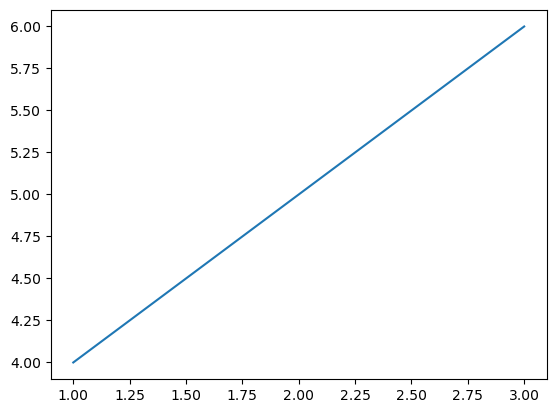

In [4]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [4, 5, 6])
plt.show()  # 🌟 运行这个格子

# 试试键入表格
| 样本编号 | 组织类型 | 测序质量（Q30）|
|  :--- | :---: | ---: |
| Tumor-01 | 肺癌组织 | 94.5% |
| Normal-01 | 癌旁对照 | 96.2% |

- [x] 成功用 requests 拦截 Erastin 的 SMILES 数据
- [x] 搞懂 `defaultdict` 自动建档小秘书的原理
- [ ] 斩落 Stage 0.5 最终章的 Excel 洗板大项目 🚀

```R
sapply(1:10, function(x) x^2)

**两个星号夹住划重点**  

*一个星号夹住变斜体*  

~~两个波浪线夹住是删除线~~  

`这个是加小方框吧？`


>假装引用


[直达阿司匹林页面](https://pubchem.ncbi.nlm.nih.gov)

                  siNC        siDMT1  
DMT1 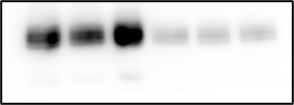

# 1  
## 2  
### 3  
#### 4  
##### 5  
###### 6  
<span style="font-size: 12px;">我是迷你小字，适合写冷知识注脚。</span>
<span style="font-size: 20px;">我是中等大字，适合用来画重点！</span>  
默认大小  
实验结果呈<span style= "color: red; font-weight: bold;">强阳性</span>

<span style= "font-size: 16px">对应12pt小四号</span>  
<span style= "font-size: 14px">对应10.5pt的五号</span>  
<span style= "font-size: 12px">六号小小脚注</span>  
<span style= "font-size: 21px">小标题的16pt三号</span>

In [5]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [6]:
import openpyxl 
import matplotlib.pyplot as plt
import pandas as pd
!pip install seaborn
import seaborn as sns

In [2]:
import openpyxl 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

新建一个练习用的excel

In [7]:

# 🔮 狐狸特供：充满了生信常见脏数据的原始样品单
raw_data = {
    "Sample_ID": ["Sample_01", "Sample_02", "Sample_03", None, "Sample_04", "Sample_05", "Sample_06"],
    "Compound_Name": ["Erastin", "Gefitinib", "Imatinib", None, "Sorafenib", "Aspirin", "Erastin"],
    "Concentration_mM": [10.5, None, 5.0, None, 12.4, 20.0, 10.5],
    "QC_Status": ["Passed", "Pending", "Passed", None, "Passed", "Passed", "Passed"]
}

# 🏭 把它们组装成 Pandas 矩阵
df = pd.DataFrame(raw_data)

# 💾 啪唧！直接在小猫当前的文件夹里生成一份名为 raw_samples.csv 的练习表格！
df.to_csv("raw_samples.csv", index=False)
print("📂 [成功] 练习用原始样品单已成功降临在你的文件夹中！")

📂 [成功] 练习用原始样品单已成功降临在你的文件夹中！


In [4]:
import numpy as np
# 清洗表格
df = pd.read_csv("raw_samples.csv")
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.dropna(subset=["Compound_Name", "Concentration_mM"])
df = df.drop_duplicates()

In [7]:
df

,Sample_ID,Compound_Name,Concentration_mM,QC_Status
0,Sample_01,Erastin,10.5,Passed
2,Sample_03,Imatinib,5.0,Passed
4,Sample_04,Sorafenib,12.4,Passed
5,Sample_05,Aspirin,20.0,Passed
6,Sample_06,Erastin,10.5,Passed


In [8]:
# 接入PubChem API
import requests
import time
def fetch_smiles(compound_name):
    print(f"📡 正在前往 PubChem 拦截: {compound_name}...")
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound_name}/property/CanonicalSMILES/JSON"
        response = requests.get(url, timeout = 5)
        data = response.json()

        #提取smiles，一层一层进行
        smiles = data['PropertyTable']['Properties'][0]['ConnectivitySMILES']
        return smiles
    except Exception as e:
        return "Not Found"
    
time.sleep(1)
#添加到df里
df['SMILES'] = df['Compound_Name'].apply(fetch_smiles)

📡 正在前往 PubChem 拦截: Erastin...
📡 正在前往 PubChem 拦截: Imatinib...
📡 正在前往 PubChem 拦截: Sorafenib...
📡 正在前往 PubChem 拦截: Aspirin...
📡 正在前往 PubChem 拦截: Erastin...


In [9]:
df

,Sample_ID,Compound_Name,Concentration_mM,QC_Status,SMILES
0,Sample_01,Erastin,10.5,Passed,CCOC1=CC=CC=C1N2C(=O)C3=CC=CC=C3N=C2C(C)N4CCN(...
2,Sample_03,Imatinib,5.0,Passed,CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C...
4,Sample_04,Sorafenib,12.4,Passed,CNC(=O)C1=NC=CC(=C1)OC2=CC=C(C=C2)NC(=O)NC3=CC...
5,Sample_05,Aspirin,20.0,Passed,CC(=O)OC1=CC=CC=C1C(=O)O
6,Sample_06,Erastin,10.5,Passed,CCOC1=CC=CC=C1N2C(=O)C3=CC=CC=C3N=C2C(C)N4CCN(...


成功保存！


C:\Users\liche\AppData\Local\Temp\ipykernel_10600\78988774.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Compound_Name", y = "Concentration_mM", data=df, palette="flare")


<function matplotlib.pyplot.show(close=None, block=None)>

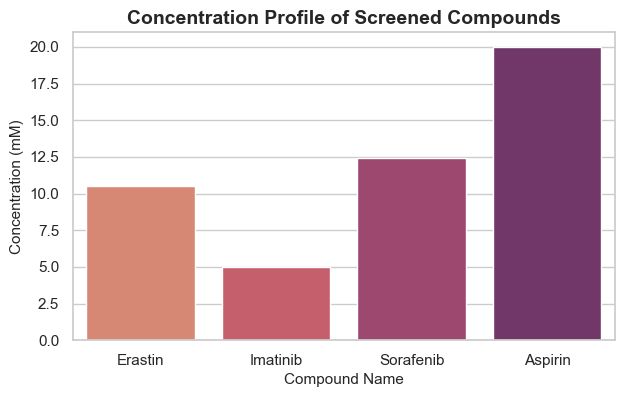

In [10]:
df.to_excel("compound_info.xlsx", index=False)
print("成功保存！")
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (7,4))
sns.barplot(x = "Compound_Name", y = "Concentration_mM", data=df, palette="flare")
plt.title("Concentration Profile of Screened Compounds", fontsize = 14, fontweight = "bold")
plt.xlabel("Compound Name", fontsize = 11)
plt.ylabel("Concentration (mM)", fontsize = 11)

plt.show

